# PBC local Chern marker on the Haldane model

In this example we are reproducing the plot of the home page of the documentation using the postprocessing module of ``StraWBerryPy``. Then, we will compute the bare marker in order to trace it and get a global topological invariant that we compare with the single-point Chern number computed previously.

In [1]:
import numpy as np
from strawberrypy import *

# Define the PBC model
pbc_model = example_models.haldane_tbmodels(
      delta = 0.3, t = 1, t2 = 0.15, phi = np.pi / 2
   )

# Build the supercell of the model
model = Model(
      model = pbc_model, spinful = False
   ).make_supercell(Lx = 30, Ly = 30)

# Add on-site Anderson disorder
model.add_disorder_uniform(w = 4, seed = 0)

# Evaluate the single-point Chern number
sp_inv = model.single_point_chern()

# Evaluate the PBC local Chern marker
pbclcm = model.pbc_local_chern_marker(
      macroscopic_average = True, cutoff = 2
   )

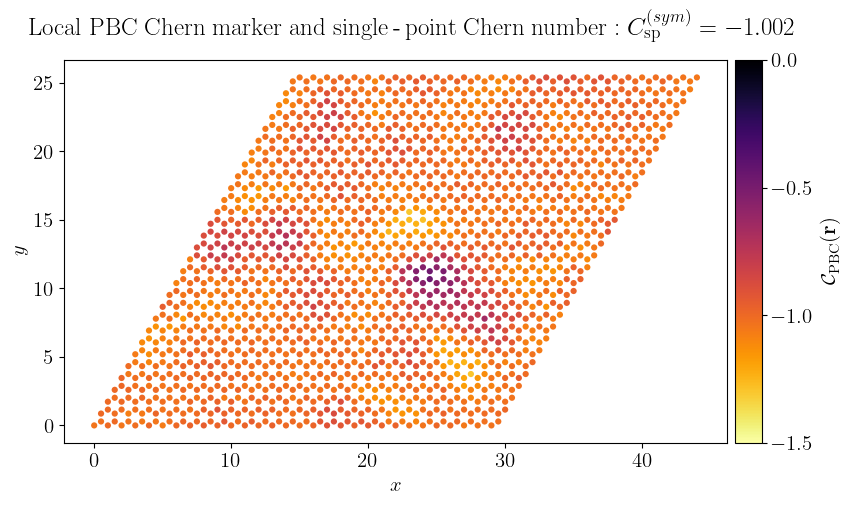

In [2]:
import matplotlib.pyplot as plt

try:
    plt.rcParams.update({'font.size': 15, 'text.usetex': True})
    plt.rcParams['text.latex.preamble'] = r'\usepackage{siunitx}'
except:
    pass

# Plot using the postprocessing function
fig, ax = postprocessing.plot_marker(
    model, marker = pbclcm, 
    cmap = 'inferno_r', vmin = -1.5, vmax = 0, s = 20
)

# Customize the plot
fig.set_size_inches(9, 7)

ax.set_aspect('equal')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

cb = fig.axes[-1]._colorbar
cb.set_ticks([-1.5, -1, -0.5, 0])
cb.set_label(r'$\mathcal C_{\mathrm{PBC}}(\mathbf r)$')

title_text = r'$\mathrm{Local\;PBC\;Chern\;marker\; and\;'          \
    + r'single}\,\text{-}\,\mathrm{point\; Chern\; number:\;}$'     \
    + r'$C^{(sym)}_{\mathrm{sp}}=' + f"{sp_inv['symmetric']:.3f}"   \
    + r"$"

fig.suptitle(title_text, x=0.5125, y=0.84);

In [3]:
fig.savefig(
    'pbc_lcm_index.png', transparent = True,
    bbox_inches = 'tight', dpi = 600
)

In [ ]:
# Get the single-point invariant by tracing the bare PBC local Chern marker
pbclcm_bare = model.pbc_local_chern_marker(bare_marker = True)
inv_from_trace = postprocessing.trace_marker(
    model, marker = pbclcm_bare, bare_marker=True
)

print(f"Single-point invariant from function: {sp_inv['symmetric']}")
print(f"Single-point invariant from trace: {inv_from_trace}")

Single-point invariant from function: -1.0022675700828267
Single-point invariant from trace: -1.0022675700828265
